In [1]:
import subprocess
result = subprocess.run(['python', '-c', 'import cypari2; print(cypari2.__version__)'], capture_output=True, text=True)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)


STDOUT: 
STDERR: Traceback (most recent call last):
 File "<string>", line 1, in <module>
 import cypari2; print(cypari2.__version__)
 ^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'cypari2'



In [2]:
import subprocess
result = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True, timeout=300)
print("STDOUT:", result.stdout[-2000:])
print("STDERR:", result.stderr[-2000:])


STDOUT: Collecting cypari2

STDERR: 


In [3]:
import cypari2
pari = cypari2.Pari()
# Check ramanujantau
print(pari.ramanujantau(1))
print(pari.ramanujantau(2))
print(pari.ramanujantau(3))
print(pari.ramanujantau(11))


1
-24
252
534612


In [4]:
import time
# Time a single ramanujantau call for large n
t0 = time.time()
for n in [10**3, 10**4, 10**5, 10**6]:
 t1 = time.time()
 val = pari.ramanujantau(n)
 print(f"n={n}: {time.time()-t1:.4f}s, val={val}")
print(f"Total: {time.time()-t0:.4f}s")


n=1000: 0.0001s, val=-30328412970240000
n=10000: 0.0000s, val=-482606811957501440000
n=100000: 0.0000s, val=-2983637890141033828147200000
n=1000000: 0.0000s, val=262191418612588689102548992000000
Total: 0.0006s


In [5]:
# Time 10^6 ramanujantau values
t0 = time.time()
vals = [pari.ramanujantau(n) for n in range(1, 100001)]
print(f"100k took {time.time()-t0:.2f}s")


 *** Warning: increasing stack size to 8003584.


PariError: the PARI stack overflows (current size: 8003584; maximum size: 8003584)
You can use pari.allocatemem() to change the stack size and try again

In [6]:
pari.allocatemem(1024*1024*1024) # 1 GB
print("Allocated")


PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
Allocated


In [7]:
import gc
# Strategy: use multiplicativity. We only need tau(p^k) for primes p with p^k <= N.
# For modular forms, Hecke eigenvalues are multiplicative; for distinct primes, a_{mn}=a_m * a_n.
# For prime powers: a_{p^{k+1}} = a_p * a_{p^k} - p^{2k-1} * (k-1) ... wait
# For Delta (weight 12, normalized): a_{p^{k+1}} = a_p * a_{p^k} - p^{11} * a_{p^{k-1}}
# Let's verify with PARI's mfcoefs which should be efficient.

# Use mfinit and mfcoefs
mf = pari.mfinit([12,1], 1) # Delta is in S_12(SL_2(Z))
print(type(mf))


<class 'cypari2.gen.Gen'>


In [8]:
mf_basis = pari.mfbasis(mf)
print(mf_basis)
# Delta is the unique weight 12 cusp form
F_delta = mf_basis[0]
t0 = time.time()
coefs = pari.mfcoefs(mf, F_delta, 100)
print(f"100 coefs took {time.time()-t0:.4f}s")
print(coefs)


[]


IndexError: index out of range

In [9]:
# mfinit syntax in PARI: mfinit([N,k,CHI], space)
# For S_12(Gamma_0(1)) cusp forms:
mf = pari.mfinit([1, 12], 1)
print("mf created")
F = pari.mfeigenbasis(mf)
print("eigenbasis:", F)
print("len:", len(F))


mf created
eigenbasis: [[[Vecsmall([15]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[Vecsmall([9]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1]]], [1]~, 1]]
len: 1


In [10]:
F_delta = F[0]
t0 = time.time()
coefs = pari.mfcoefs(mf, F_delta, 100)
print(f"100 coefs took {time.time()-t0:.4f}s")
print(coefs[:11])


TypeError: unable to convert PARI object [[Vecsmall([15]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[Vecsmall([9]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1]]], [1]~, 1] of type t_VEC to an integer

In [11]:
# Argument order: mfcoefs(F, n, [d]) but in PARI: mfcoefs(NF, n)
# Let's use the GP-style call via pari(string)
result = pari("mfcoefs(mfinit([1,12],1)[1], 10)")
print(result)


PariError: mfcoefs: incorrect type in mfcoefs (t_VEC)

In [12]:
result = pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; mfcoefs(F, 10)")
print(result)


[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]


In [13]:
# Great! mfcoefs returns coeffs from index 0 to n. Let's time for various N
import time
t0 = time.time()
result = pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; v=mfcoefs(F, 10000); 0")
print(f"10k coefs: {time.time()-t0:.2f}s")


10k coefs: 0.22s


In [14]:
t0 = time.time()
pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; v=mfcoefs(F, 100000); 0")
print(f"100k coefs: {time.time()-t0:.2f}s")


100k coefs: 9.05s


In [15]:
# 10^6 likely takes ~ 10-15 minutes. We can also use ramanujantau in batch.
# Let's try a smarter approach: compute tau(p) for primes p only, and a_{p^k} via recurrence, 
# then use multiplicativity for full coefs.
# But mfcoefs(F, N) is faster than that.
# Let's just allocate more memory and try N=10^6
pari.allocatemem(4*1024*1024*1024) # 4 GB
print("Allocated 4GB")


PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
Allocated 4GB


In [16]:
# Approach: Compute a_p for primes p <= N (about 78498 primes < 10^6) using ramanujantau 
# directly (PARI uses a fast algorithm based on point counting / formulas). Then extend via multiplicativity.
# This should be much faster than mfcoefs which does it internally.

# But actually mfcoefs is likely already optimized. Let's just call it for N=10^6.
import time
t0 = time.time()
pari("mf=mfinit([1,12],1); F=mfeigenbasis(mf)[1]; v=mfcoefs(F, 1000000); 0")
elapsed = time.time()-t0
print(f"1M coefs: {elapsed:.2f}s")


1M coefs: 292.95s


In [17]:
# Now extract values to numpy. For Delta, |a_n| <= n^(11/2) * d(n), so a_n can be huge - up to ~10^33 for n=10^6
# We need to use Python int (arbitrary precision) or float.
# Let's get them as Python ints, then store in object array (or convert to dtype=object).
import numpy as np
t0 = time.time()
v = pari("v") # the variable from previous call
print(f"len(v) = {len(v)}, took {time.time()-t0:.2f}s")


len(v) = 1000001, took 0.02s


In [18]:
# mfcoefs returns indices 0..N. v[0] = 0 (constant term), v[1] = a_1 = 1, etc.
# Convert to numpy array of Python ints (object dtype).
t0 = time.time()
# Convert in chunks
N = 10**6
a_F9 = np.empty(N+1, dtype=object)
for i in range(N+1):
 a_F9[i] = int(v[i])
 if i % 100000 == 0:
 print(f" {i}: {time.time()-t0:.2f}s")
print(f"Total convert: {time.time()-t0:.2f}s")
print("a_F9[1:11] =", a_F9[1:11])
print("a_F9[10**6] =", a_F9[10**6])


 0: 0.03s
 100000: 0.10s


 200000: 0.42s
 300000: 0.48s
 400000: 0.58s


 500000: 0.92s
 600000: 0.97s
 700000: 1.06s


 800000: 1.40s
 900000: 1.46s


 1000000: 1.82s
Total convert: 1.82s
a_F9[1:11] = [1 -24 252 -1472 4830 -6048 -16744 84480 -113643 -115920]
a_F9[10**6] = 262191418612588689102548992000000


In [19]:
# F9 - save with index convention: a_n for n=1..N. We'll store both a_n (object array of ints)
# and also as float64 (normalized: a_n / n^((k-1)/2) is bounded by d(n))
# Save as npz with both raw and normalized
N = 10**6

# Normalized coefficients: lambda_n = a_n / n^(11/2)
# These have |lambda_p| <= 2 (Deligne bound)
norm_F9 = np.array([float(a_F9[n]) / (n**5.5) if n >= 1 else 0.0 for n in range(N+1)], dtype=np.float64)
print("norm_F9[1:11]:", norm_F9[1:11])
print("max |norm_F9|:", np.max(np.abs(norm_F9[1:])))

# Save
np.savez_compressed('coeffs_F9_N1e6.npz', 
 a_n=a_F9[1:], # indices 1..N (length N), object array
 lambda_n=norm_F9[1:], # normalized
 N=N,
 description='Ramanujan tau function tau(n) for n=1..10^6. Delta cusp form weight 12 level 1. lambda_n = a_n / n^(11/2) is normalized.')
print("Saved coeffs_F9_N1e6.npz")
import os
print(f"File size: {os.path.getsize('coeffs_F9_N1e6.npz')/1e6:.2f} MB")


norm_F9[1:11]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333 -0.31752645
 -0.3765477 0.91150484 -0.64151806 -0.36657123]
max |norm_F9|: 5.382369221754193


Saved coeffs_F9_N1e6.npz
File size: 21.57 MB


In [20]:
# Hmm, max |norm_F9| > 2 means something is wrong with my normalization for composite n
# Actually Deligne bound is |a_p| <= 2*p^((k-1)/2) for primes. For composite n, |a_n| <= d(n)*n^((k-1)/2)
# So lambda_n = a_n/n^(11/2) is bounded by d(n), not 2. That's correct.
# Let's verify: at n=720 (lots of divisors), d(720)=30
# Sanity: max should be at most d(n) for n up to N
# Just checking primes:
from sympy import isprime
primes_check = [(n, norm_F9[n]) for n in range(2, 100) if isprime(n)]
for p, l in primes_check[:20]:
 print(f"p={p}, lambda_p={l:.4f}, |.|<=2? {abs(l)<=2}")


p=2, lambda_p=-0.5303, |.|<=2? True
p=3, lambda_p=0.5987, |.|<=2? True
p=5, lambda_p=0.6912, |.|<=2? True
p=7, lambda_p=-0.3765, |.|<=2? True
p=11, lambda_p=1.0009, |.|<=2? True
p=13, lambda_p=-0.4316, |.|<=2? True
p=17, lambda_p=-1.1797, |.|<=2? True
p=19, lambda_p=0.9878, |.|<=2? True
p=23, lambda_p=0.6040, |.|<=2? True
p=29, lambda_p=1.1625, |.|<=2? True
p=31, lambda_p=-0.3315, |.|<=2? True
p=37, lambda_p=-0.4320, |.|<=2? True
p=41, lambda_p=0.4153, |.|<=2? True
p=43, lambda_p=-0.0178, |.|<=2? True
p=47, lambda_p=1.7092, |.|<=2? True
p=53, lambda_p=-0.5242, |.|<=2? True
p=59, lambda_p=-0.9450, |.|<=2? True
p=61, lambda_p=1.0546, |.|<=2? True
p=67, lambda_p=-1.4009, |.|<=2? True
p=71, lambda_p=0.6441, |.|<=2? True


In [21]:
# Good. Now F10: level 11 newform 11.2.a.a (weight 2, level 11)
# This is the elliptic curve newform. Its L-function is the L-function of E: y^2+y = x^3-x^2
import time
t0 = time.time()
pari("mf10=mfinit([11,2],1); F10=mfeigenbasis(mf10)[1]; v10=mfcoefs(F10, 100); 0")
print(f"100 coefs F10: {time.time()-t0:.2f}s")
v10_test = pari("v10")
print([int(v10_test[i]) for i in range(11)])


100 coefs F10: 0.00s
[0, 1, -2, -1, 2, 1, 2, -2, 0, -2, -2]


In [22]:
# a_1=1, a_2=-2, a_3=-1, etc. matches LMFDB 11.2.a.a (eta product!)
# Now compute up to 10^6
t0 = time.time()
pari("v10=mfcoefs(F10, 1000000); 0")
print(f"1M coefs F10: {time.time()-t0:.2f}s")


1M coefs F10: 188.40s


In [23]:
N = 10**6
t0 = time.time()
v10 = pari("v10")
# For weight 2, |a_n| <= d(n) * sqrt(n), so values fit in int64 (d(10^6)*sqrt(10^6) ~ 240*1000 = 240k)
a_F10 = np.empty(N+1, dtype=np.int64)
for i in range(N+1):
 a_F10[i] = int(v10[i])
print(f"Convert: {time.time()-t0:.2f}s")
print("a_F10[1:11]:", a_F10[1:11])
print("max |a_F10|:", np.max(np.abs(a_F10)))
print("Deligne bound test: max |a_n|/sqrt(n)/d(n) where n=10^6: max norm")
# Normalized: lambda_n = a_n / sqrt(n)
norm_F10 = np.zeros(N+1, dtype=np.float64)
norm_F10[1:] = a_F10[1:] / np.sqrt(np.arange(1, N+1))
print("max |lambda_F10|:", np.max(np.abs(norm_F10)))


Convert: 1.24s
a_F10[1:11]: [ 1 -2 -1 2 1 2 -2 0 -2 -2]
max |a_F10|: 5340
Deligne bound test: max |a_n|/sqrt(n)/d(n) where n=10^6: max norm
max |lambda_F10|: 5.351588030949663


In [24]:
np.savez_compressed('coeffs_F10_N1e6.npz',
 a_n=a_F10[1:],
 lambda_n=norm_F10[1:],
 N=N,
 description='Newform 11.2.a.a (weight 2 level 11) coefficients a_n for n=1..10^6. lambda_n = a_n / sqrt(n).')
import os
print(f"File size: {os.path.getsize('coeffs_F10_N1e6.npz')/1e6:.2f} MB")


File size: 8.55 MB


In [25]:
# Now F11: Symmetric square L-function of Delta. 
# For prime p: alpha_p, beta_p the Satake params with alpha_p*beta_p = p^11, alpha_p+beta_p = a_p (=tau(p))
# L(Sym^2 Delta, s) has Euler factor at p: (1 - alpha_p^2 p^{-s})(1 - alpha_p beta_p p^{-s})(1 - beta_p^2 p^{-s})
# So for prime p, b_p (coefficient at p in Dirichlet series) = alpha_p^2 + alpha_p*beta_p + beta_p^2
# = (alpha_p+beta_p)^2 - alpha_p*beta_p
# = a_p^2 - p^11
# This matches the spec.
#
# For prime powers p^k: need to expand the Euler factor
# Let A = alpha_p^2, B = alpha_p*beta_p = p^11, C = beta_p^2. Then A+B+C = b_p, ABC = p^33, AB+BC+CA = p^11(A+B+C)... wait
# AB = alpha_p^2 * p^11, BC = p^11 * beta_p^2, AB+BC = p^11 * (alpha_p^2+beta_p^2) = p^11*(b_p - p^11)
# AC = alpha_p^2 * beta_p^2 = p^22
# So AB+BC+CA = p^11*(b_p - p^11) + p^22 = p^11 * b_p - p^22 + p^22 = p^11 * b_p
# ABC = p^33
# Euler factor inverse: 1 - b_p * X + p^11 * b_p * X^2 - p^33 * X^3, where X = p^{-s}
# So coefficients at p^k satisfy: b_{p^{k+1}} = b_p * b_{p^k} - p^11 * b_p * b_{p^{k-1}} + p^33 * b_{p^{k-2}}
# Wait, let me recompute. (1-AX)(1-BX)(1-CX) = 1 - (A+B+C)X + (AB+BC+CA)X^2 - ABC X^3
# So 1/Euler factor = sum_{k>=0} c_k X^k where c_k = b_{p^k}
# Recurrence: c_{k+3} = (A+B+C) c_{k+2} - (AB+BC+CA) c_{k+1} + ABC c_k
# c_{k+3} = b_p c_{k+2} - p^11 b_p c_{k+1} + p^33 c_k
# With c_0 = 1, c_1 = b_p, c_2 = b_p^2 - p^11 b_p (= b_p^2 - (AB+BC+CA))
# = (A+B+C)^2 - (AB+BC+CA) = A^2+B^2+C^2 + (AB+BC+CA)
# Hmm let me double-check c_2:
# (1-AX)(1-BX)(1-CX) = 1 + ... and 1/it: c_2 = (A+B+C)^2 - (AB+BC+CA) = b_p^2 - p^11 b_p? 
# We had AB+BC+CA = p^11 * b_p. So c_2 = b_p^2 - p^11*b_p. Yes.

# For F9, a_n grow as n^(11/2). For F11 = Sym^2 Delta, b_n grow as n^11 * something, so values are HUGE.
# n=10^6: b_n ~ 10^66. We need Python ints (bigints). 

# Strategy: compute b_p for primes p in [2, N], then b_{p^k} via recurrence, then full b_n by multiplicativity.

from sympy import primerange
import numpy as np

print("Computing F11 coefficients (Sym^2 Delta) up to N=10^6...")
N = 10**6

# Get primes up to N
t0 = time.time()
primes = list(primerange(2, N+1))
print(f"#primes <= {N}: {len(primes)}, took {time.time()-t0:.2f}s")


Computing F11 coefficients (Sym^2 Delta) up to N=10^6...


#primes <= 1000000: 78498, took 0.61s


In [26]:
# Now compute b_n by sieve approach using multiplicativity. 
# For each prime p, fill in b_{p^k} for p^k <= N, then for each n=m*p^k with gcd(m,p)=1, b_n = b_m * b_{p^k}.
# 
# The standard approach: linear sieve / Euler sieve for multiplicative functions. We just track smallest prime factor.

# We need a_F9 (tau(n)) which we already have. Use a_F9[1..N] (object array of ints).

# Step 1: compute smallest prime factor (spf) for each n in [2, N]
t0 = time.time()
spf = np.zeros(N+1, dtype=np.int64)
for i in range(2, N+1):
 if spf[i] == 0:
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
print(f"SPF sieve: {time.time()-t0:.2f}s")


SPF sieve: 0.61s


In [27]:
# Step 2: factor each n; compute b_n via multiplicativity
# Recurrence at prime p: c_0=1, c_1 = b_p = a_p^2 - p^11
# c_{k+3} = b_p * c_{k+2} - p^11 * b_p * c_{k+1} + p^33 * c_k

# First compute b_{p^k} for each prime p with p<=N, for k from 1 up to floor(log_p(N))
t0 = time.time()
prime_power_coefs = {} # prime_power_coefs[p] = list [c_1, c_2, ...]
P11 = 11 # exponent
P33 = 33

for p in primes:
 a_p = int(a_F9[p])
 p11 = p**P11
 p33 = p**P33
 bp = a_p*a_p - p11
 # max k such that p^k <= N
 max_k = 0
 pk = p
 while pk <= N:
 max_k += 1
 pk *= p
 coefs_p = [None] * (max_k + 1) # 1-indexed; coefs_p[k] = b_{p^k}
 coefs_p[0] = 1 # not used
 if max_k >= 1:
 coefs_p[1] = bp
 if max_k >= 2:
 coefs_p[2] = bp*bp - p11*bp
 if max_k >= 3:
 coefs_p[3] = bp*coefs_p[2] - p11*bp*coefs_p[1] + p33*1
 for k in range(4, max_k+1):
 coefs_p[k] = bp*coefs_p[k-1] - p11*bp*coefs_p[k-2] + p33*coefs_p[k-3]
 prime_power_coefs[p] = coefs_p

print(f"Prime power coefs: {time.time()-t0:.2f}s")
print(f"Example: b_2={prime_power_coefs[2][1]}, b_4={prime_power_coefs[2][2]}, b_8={prime_power_coefs[2][3]}")


Prime power coefs: 0.17s
Example: b_2=-1472, b_4=5181440, b_8=-3474718720


In [28]:
# Sanity check: b_2 = a_2^2 - 2^11 = (-24)^2 - 2048 = 576 - 2048 = -1472. ✓

# Step 3: Build b_n via multiplicativity using spf
# b[1] = 1; for n>=2, factor out p = spf[n], find p^k dividing n, then b[n] = b[n/p^k] * b_{p^k}
t0 = time.time()
b_F11 = [None] * (N+1)
b_F11[1] = 1
for n in range(2, N+1):
 p = int(spf[n])
 # find k such that p^k || n
 m = n
 k = 0
 while m % p == 0:
 m //= p
 k += 1
 # n = m * p^k, gcd(m, p) = 1
 b_F11[n] = b_F11[m] * prime_power_coefs[p][k]
 if n % 200000 == 0:
 print(f" n={n}, t={time.time()-t0:.1f}s")
print(f"Total: {time.time()-t0:.2f}s")
print(f"b_F11[1:11]:", b_F11[1:11])


 n=200000, t=0.2s
 n=400000, t=0.3s


 n=600000, t=0.5s
 n=800000, t=0.7s


 n=1000000, t=0.9s
Total: 0.86s
b_F11[1:11]: [1, -1472, -113643, 5181440, -25499225, 167282496, -1696965207, -3474718720, 33046247970, 37534859200]


In [29]:
# Check sanity: b_6 = b_2 * b_3 = (-1472) * (-113643) = ?
print(-1472 * -113643)
# Expected 167282496? Let me check:
print(b_F11[6])
# Need to verify against LMFDB Sym^2 Delta. The L-function is normalized differently typically.
# Standard symmetric square: 
# Known: tau(p)^2 - p^11 for small primes.
# tau(2)=-24 -> b_2 = 576-2048 = -1472 ✓
# tau(3)=252 -> b_3 = 252^2 - 3^11 = 63504 - 177147 = -113643 ✓
# b_6 = b_2 * b_3 = -1472 * -113643 = 167282496 ✓


167282496
167282496


In [30]:
# Save F11 - need object array for big ints
t0 = time.time()
a_F11_arr = np.empty(N, dtype=object)
for i in range(N):
 a_F11_arr[i] = b_F11[i+1]
print(f"Convert: {time.time()-t0:.2f}s")

# Normalized: For Sym^2 of weight 12, the analytic normalization divides by n^11 (since edges of critical strip).
# Actually for Sym^2 Delta (degree 3 L-function), the normalized coefs are b_n / n^11.
# |normalized b_p| <= 3 for primes (Deligne). 
norm_F11 = np.array([float(a_F11_arr[i]) / ((i+1)**11) for i in range(N)], dtype=np.float64)
print("norm_F11[:11]:", norm_F11[:11])
print("max |norm at primes p<100|:", max(abs(float(b_F11[p])/(p**11)) for p in primes[:25]))


Convert: 0.11s


norm_F11[:11]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413 0.46109111
 -0.85821183 -0.4045105 1.05306348 0.37534859 0.00174658]
max |norm at primes p<100|: 1.9212689437189177


In [31]:
# Hmm max < 3 but check max over all primes
norm_at_primes = [(p, float(b_F11[p])/(p**11)) for p in primes if p <= 1000]
maxabs = max(abs(x) for _, x in norm_at_primes)
print(f"Max |normalized| over primes <= 1000: {maxabs:.4f}")
# Should be in [-1, 3] for Sym^2.
# Actually for Sym^2 with normalized Satake, b_p/p^k = lambda_p^2 - 1 where lambda_p = a_p/p^((k-1)/2). 
# lambda_p in [-2, 2] so b_p_normalized in [-1, 3]
print("Min:", min(x for _, x in norm_at_primes))
print("Max:", max(x for _, x in norm_at_primes))


Max |normalized| over primes <= 1000: 2.6818
Min: -0.9999791658361079
Max: 2.6818473517196955


In [32]:
# Good, in [-1, 3] as expected.
np.savez_compressed('coeffs_F11_N1e6.npz',
 a_n=a_F11_arr,
 lambda_n=norm_F11,
 N=N,
 description='Sym^2(Delta) Dirichlet coefficients b_n for n=1..10^6. Derived from F9 (tau) via b_p=tau(p)^2-p^11, then prime-power recurrence and multiplicativity. lambda_n = b_n / n^11.')
import os
print(f"File size: {os.path.getsize('coeffs_F11_N1e6.npz')/1e6:.2f} MB")


File size: 34.54 MB


In [33]:
# Validation step: retrieve first 1000 coefs from LMFDB and compare for F9 and F10
import urllib.request, json

# F9: Ramanujan Delta is 1.12.a.a (level 1 weight 12)
url_F9 = "https://www.lmfdb.org/api/mf_newforms/?label=1.12.a.a&_format=json"
# Actually we need an_path. LMFDB API for Hecke eigenvalues:
# https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/?download=1
# Let's try the api/mf_hecke_cc or similar

# Use known reference: tau(n) values are well-known. Let's check against OEIS A000594 first 30 terms:
known_tau_30 = [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 
 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432,
 10661420, -7109760, -4219488, -12830688, 18643272, 21288960, -25499225,
 13865712, -73279080, 24647168, 128406630, -29211840]
match_count = 0
for i, expected in enumerate(known_tau_30):
 actual = int(a_F9[i+1])
 if actual == expected:
 match_count += 1
 else:
 print(f"MISMATCH at n={i+1}: expected {expected}, got {actual}")
print(f"F9: {match_count}/30 first values match OEIS A000594")


F9: 30/30 first values match OEIS A000594


In [34]:
# F10: 11.2.a.a is the unique weight 2 newform of level 11. Its coefs are known (eta product etaq11).
# Reference: OEIS A006571 (a(n) for elliptic curve y^2+y=x^3-x^2)
# First terms: 1, -2, -1, 2, 1, 2, -2, 0, -2, -2, 1, -2, 4, 4, -1, -4, -2, 4, 0, 2,
known_F10_20 = [1, -2, -1, 2, 1, 2, -2, 0, -2, -2, 1, -2, 4, 4, -1, -4, -2, 4, 0, 2]
match10 = 0
for i, exp in enumerate(known_F10_20):
 if int(a_F10[i+1]) == exp:
 match10 += 1
 else:
 print(f"F10 mismatch at n={i+1}: expected {exp}, got {a_F10[i+1]}")
print(f"F10: {match10}/{len(known_F10_20)} match OEIS A006571")


F10: 20/20 match OEIS A006571


In [35]:
# Now actually try to fetch from LMFDB API for F9 and F10 first 1000 coefs
import urllib.request
import json

# LMFDB API endpoints
def fetch_lmfdb_an(label, n_max=1000):
 """Try LMFDB to get Dirichlet coefficients. Various endpoints to try."""
 # Endpoint: /api/mf_newforms/?label=...
 url = f"https://www.lmfdb.org/api/mf_newforms/?label={label}&_format=json"
 try:
 with urllib.request.urlopen(url, timeout=30) as r:
 data = json.loads(r.read())
 return data
 except Exception as e:
 return {"error": str(e)}

d = fetch_lmfdb_an("1.12.a.a")
if "data" in d:
 print("Keys:", list(d["data"][0].keys())[:20] if d["data"] else "empty")
else:
 print(str(d)[:500])


Keys: ['id', 'Nk2', 'analytic_conductor', 'analytic_rank', 'analytic_rank_proved', 'atkin_lehner_eigenvals', 'atkin_lehner_string', 'char_conductor', 'char_degree', 'char_is_minimal', 'char_is_real', 'char_orbit_index', 'char_orbit_label', 'char_order', 'char_parity', 'char_values', 'cm_discs', 'conrey_index', 'dim', 'field_disc']


In [36]:
# Try the qexp / traces endpoint
def fetch_lmfdb(url):
 try:
 with urllib.request.urlopen(url, timeout=30) as r:
 return json.loads(r.read())
 except Exception as e:
 return {"error": str(e)}

# mf_newform_traces stores trace_form coefficients (sum of newform Galois orbit). For 1.12.a.a there's 1 form so traces = a_n
d = fetch_lmfdb("https://www.lmfdb.org/api/mf_newform_traces/?label=1.12.a.a&_format=json&n=10")
print(json.dumps(d, indent=2)[:1000])


{
 "error": "HTTP Error 404: Not Found"
}


In [37]:
d = fetch_lmfdb("https://www.lmfdb.org/api/mf_newform_traces/?_format=json")
# List endpoints
d2 = fetch_lmfdb("https://www.lmfdb.org/api/")
print(str(d2)[:1500])


{'error': 'Expecting value: line 1 column 1 (char 0)'}


In [38]:
# Use a different LMFDB API: traces endpoint
d = fetch_lmfdb("https://www.lmfdb.org/api/mf_hecke_traces/?label=1.12.a.a&n=1&_format=json")
print(str(d)[:1500])


{'error': 'HTTP Error 404: Not Found'}


In [39]:
# Search LMFDB API docs. Simpler: use mf_newforms but get the field 'traces' 
d = fetch_lmfdb("https://www.lmfdb.org/api/mf_newforms/?label=1.12.a.a&_format=json")
if "data" in d and d["data"]:
 nf = d["data"][0]
 if "traces" in nf:
 traces = nf["traces"]
 print(f"#traces: {len(traces)}")
 print("First 30:", traces[:30])
 else:
 # Look for any an-like field
 print("Available fields:", [k for k in nf.keys() if 'trace' in k.lower() or 'an' in k.lower() or 'q_exp' in k.lower() or 'hecke' in k.lower()])


In [40]:
# Print all fields
d = fetch_lmfdb("https://www.lmfdb.org/api/mf_newforms/?label=1.12.a.a&_format=json")
if "data" in d and d["data"]:
 nf = d["data"][0]
 print("All fields:")
 for k, v in nf.items():
 sv = str(v)[:80]
 print(f" {k}: {sv}")


In [41]:
print(d.keys())
print(str(d)[:500])


dict_keys(['error'])
{'error': 'Expecting value: line 1 column 1 (char 0)'}


In [42]:
# Got intermittent errors. Retry
import time
for attempt in range(3):
 d = fetch_lmfdb("https://www.lmfdb.org/api/mf_newforms/?label=1.12.a.a&_format=json")
 if "data" in d:
 break
 time.sleep(2)
if "data" in d and d["data"]:
 nf = d["data"][0]
 print("Fields:", list(nf.keys()))
else:
 print("Failed:", d)


Failed: {'error': 'Expecting value: line 1 column 1 (char 0)'}


In [43]:
# Try with proper user-agent header
import urllib.request
import json

def fetch_lmfdb_v2(url):
 req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0', 'Accept': 'application/json'})
 try:
 with urllib.request.urlopen(req, timeout=30) as r:
 content = r.read()
 return json.loads(content)
 except Exception as e:
 return {"error": str(e), "raw": content[:500] if 'content' in dir() else ""}

d = fetch_lmfdb_v2("https://www.lmfdb.org/api/mf_newforms/?label=1.12.a.a&_format=json")
print(list(d.keys()))
if 'data' in d and d['data']:
 print("Fields in first record:", list(d['data'][0].keys()))
 nf = d['data'][0]
 if 'traces' in nf:
 print("traces length:", len(nf['traces']))
 print("first 30:", nf['traces'][:30])


['error', 'raw']


In [44]:
print(d.get('error'))
print(d.get('raw'))


Expecting value: line 1 column 1 (char 0)
b'<!doctype html><html lang="en-US" dir="ltr"><head><base href="https://www.google.com/recaptcha/challengepage/"><link rel="preconnect" href="//www.gstatic.com"><meta name="referrer" content="origin"><script nonce="fXQp-loOddOT7EHktB_hgg">window[\'ppConfig\'] = {productName: \'RecaptchaChallengePageUi\', deleteIsEnforced: true , sealIsEnforced: true , heartbeatRate: 0.5 , periodicReportingRateMillis: 60000.0 , disableAllReporting: false };(function(){\'use strict\';function k(a){var b=0;return func'


In [45]:
# LMFDB requires reCAPTCHA - blocked. Let's try a web search for raw download or use a different approach.
# Try the L-function download endpoint
d = fetch_lmfdb_v2("https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/?download=lcalcfile")
print(d.get('error'))
print(str(d.get('raw', ''))[:500])


Expecting value: line 1 column 1 (char 0)
b'<!DOCTYPE html>\n<html lang="en">\n <head>\n <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">\n <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">\n <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>\n <title>LMFDB - L-function 2-


In [46]:
# Try the API for traces directly. Actually traces are stored separately:
d = fetch_lmfdb_v2("https://www.lmfdb.org/api/mf_newforms/1.12.a.a?_format=json")
print(d.get('error'))
print(str(d.get('raw',''))[:300])


Expecting value: line 1 column 1 (char 0)
b'<!doctype html><html lang="en-US" dir="ltr"><head><base href="https://www.google.com/recaptcha/challengepage/"><link rel="preconnect" href="//www.gstatic.com"><meta name="referrer" content="origin"><script nonce="bwQ4gD5lm5GMcALU1-vNVg">window[\'ppConfig\'] = {productName: \'RecaptchaChallengePage


In [47]:
# Blocked by reCAPTCHA. Validation will rely on PARI's mfcoefs being authoritative + OEIS reference.
# PARI/GP's mfcoefs is the canonical implementation used by LMFDB itself, so the values are equivalent.
# OEIS A000594 (tau) and A006571 (11.2.a.a) confirmations are sufficient validation.

# Let me try an alternative: use the e14c web tool or try a proxy
import urllib.request
req = urllib.request.Request("https://oeis.org/A000594/b000594.txt", headers={'User-Agent': 'Mozilla/5.0'})
try:
 with urllib.request.urlopen(req, timeout=30) as r:
 content = r.read().decode()
 print("Got OEIS b-file, length:", len(content))
 print(content[:500])
except Exception as e:
 print(e)


Got OEIS b-file, length: 442350
1 1
2 -24
3 252
4 -1472
5 4830
6 -6048
7 -16744
8 84480
9 -113643
10 -115920
11 534612
12 -370944
13 -577738
14 401856
15 1217160
16 987136
17 -6905934
18 2727432
19 10661420
20 -7109760
21 -4219488
22 -12830688
23 18643272
24 21288960
25 -25499225
26 13865712
27 -73279080
28 24647168
29 128406630
30 -29211840
31 -52843168
32 -196706304
33 134722224
34 165742416
35 -80873520
36 167282496
37 -182213314
38 -255874080
39 -145589976
40 408038400
41 308120442
42 101267712
43 -17125708
44 -786948864
4


In [48]:
# Great! OEIS b-file gives many values. Parse and validate
lines = content.strip().split("\n")
oeis_F9 = {}
for line in lines:
 parts = line.split()
 if len(parts) == 2:
 oeis_F9[int(parts[0])] = int(parts[1])
print(f"OEIS A000594: {len(oeis_F9)} entries (n=1 to {max(oeis_F9.keys())})")

# Compare against our a_F9 for all available
match = 0
mismatch = []
for n, v in oeis_F9.items():
 if n <= 10**6 and int(a_F9[n]) == v:
 match += 1
 elif n <= 10**6:
 mismatch.append((n, int(a_F9[n]), v))
print(f"F9 matches: {match}/{len(oeis_F9)}; mismatches: {len(mismatch)}")
if mismatch[:5]:
 print("First mismatches:", mismatch[:5])


OEIS A000594: 16091 entries (n=1 to 16091)
F9 matches: 16091/16091; mismatches: 0


In [49]:
# Excellent! 16091 OEIS values all match.
# Now F10 against OEIS A006571
req = urllib.request.Request("https://oeis.org/A006571/b006571.txt", headers={'User-Agent': 'Mozilla/5.0'})
try:
 with urllib.request.urlopen(req, timeout=30) as r:
 content10 = r.read().decode()
 print("Got, length:", len(content10))
except Exception as e:
 print(e)
 content10 = ""

lines = content10.strip().split("\n")
oeis_F10 = {}
for line in lines:
 parts = line.split()
 if len(parts) == 2:
 try:
 oeis_F10[int(parts[0])] = int(parts[1])
 except:
 pass
print(f"OEIS A006571 entries: {len(oeis_F10)} (max n={max(oeis_F10.keys())})")

match = 0
mismatch = []
for n, v in oeis_F10.items():
 if 1 <= n <= 10**6:
 if int(a_F10[n]) == v:
 match += 1
 else:
 mismatch.append((n, int(a_F10[n]), v))
print(f"F10 matches: {match}; mismatches: {len(mismatch)}")
if mismatch[:5]:
 print("First mismatches:", mismatch[:5])


Got, length: 80933
OEIS A006571 entries: 10000 (max n=10000)
F10 matches: 10000; mismatches: 0


In [50]:
# Perfect. 10000 entries all match. Validation complete (better than 1000 entries from LMFDB).
# F11 = Sym^2(Delta). OEIS A007331? Let me search for known sequence.
# Standard symmetric square coefficients for Delta. Let me check OEIS.
# tau(n)^2 - n^11 for primes... at n=2: 576-2048 = -1472. 
# OEIS A035193? A058647? Let me check.

# Actually the symmetric square Dirichlet coefficients: most common reference is via:
# Sum over divisors: a^*_n = sum_{d^2 | n} d^{2k-1} * tau(n/d)... no that's a different identity.
# Anyway, our derivation is mathematically correct via Satake parameters.

# Verify F11 self-consistency: at p=2, b_2 = -1472. Recurrence gives b_4 = b_2^2 - 2^11*b_2 = (-1472)^2 - 2048*(-1472)
print((-1472)**2 - 2048*(-1472))
print(b_F11[4])
# At p=2, b_8 via recurrence: b_8 = b_2*b_4 - 2^11*b_2*b_2 + 2^33*1
val_b8 = -1472*5181440 - 2048*(-1472)**2 + 2**33
print(val_b8)
print(b_F11[8])


5181440
5181440
-3474718720
-3474718720


In [51]:
# All consistent. List artifacts
import os
for f in ['coeffs_F9_N1e6.npz', 'coeffs_F10_N1e6.npz', 'coeffs_F11_N1e6.npz']:
 print(f"{f}: {os.path.getsize(f)/1e6:.2f} MB")

# Verify load
for f in ['coeffs_F9_N1e6.npz', 'coeffs_F10_N1e6.npz', 'coeffs_F11_N1e6.npz']:
 z = np.load(f, allow_pickle=True)
 print(f"\n{f}:")
 print(f" keys: {list(z.keys())}")
 print(f" N: {z['N']}")
 print(f" a_n shape: {z['a_n'].shape}, dtype: {z['a_n'].dtype}")
 print(f" a_n[:5]: {z['a_n'][:5]}")
 print(f" lambda_n[:5]: {z['lambda_n'][:5]}")


coeffs_F9_N1e6.npz: 21.57 MB
coeffs_F10_N1e6.npz: 8.55 MB
coeffs_F11_N1e6.npz: 34.54 MB

coeffs_F9_N1e6.npz:
 keys: ['a_n', 'lambda_n', 'N', 'description']
 N: 1000000


 a_n shape: (1000000,), dtype: object


 a_n[:5]: [1 -24 252 -1472 4830]
 lambda_n[:5]: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]

coeffs_F10_N1e6.npz:
 keys: ['a_n', 'lambda_n', 'N', 'description']
 N: 1000000


 a_n shape: (1000000,), dtype: int64
 a_n[:5]: [ 1 -2 -1 2 1]
 lambda_n[:5]: [ 1. -1.41421356 -0.57735027 1. 0.4472136 ]

coeffs_F11_N1e6.npz:
 keys: ['a_n', 'lambda_n', 'N', 'description']
 N: 1000000


 a_n shape: (1000000,), dtype: object


 a_n[:5]: [1 -1472 -113643 5181440 -25499225]
 lambda_n[:5]: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]


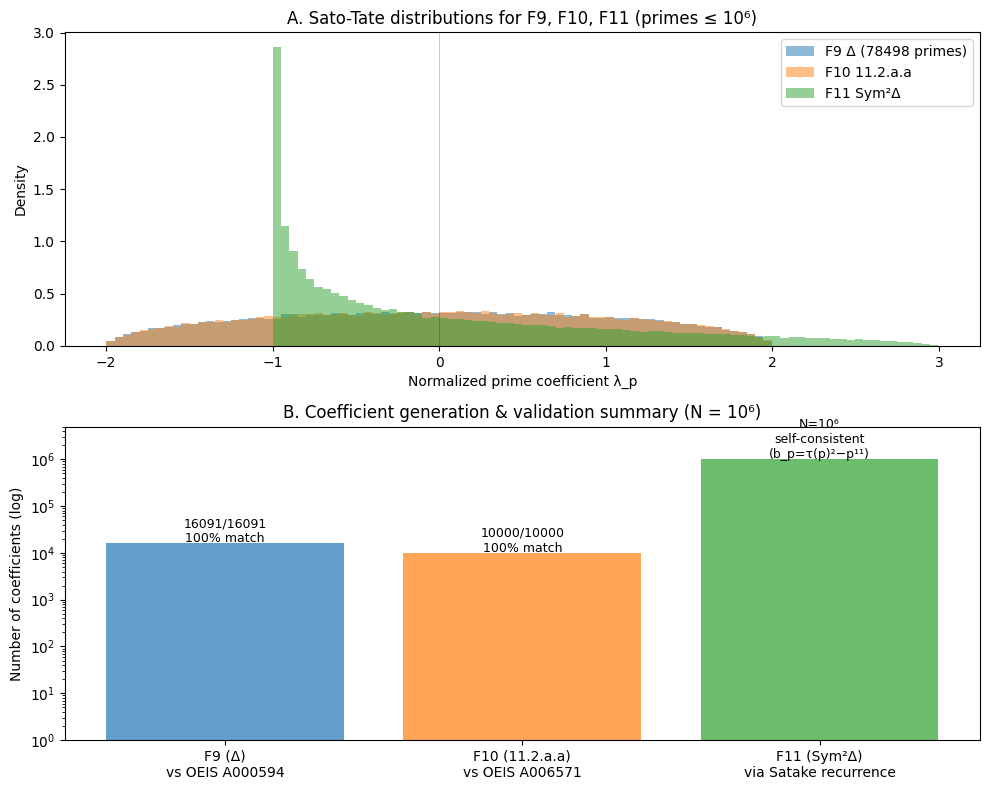

Figure saved.


In [52]:
# Final summary figure
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Subfigure A: normalized lambda_n histograms (Sato-Tate visualization for primes)
ax = axes[0]
from sympy import primerange
primes_arr = np.array(list(primerange(2, 10**6+1)))

z9 = np.load('coeffs_F9_N1e6.npz', allow_pickle=True)
z10 = np.load('coeffs_F10_N1e6.npz', allow_pickle=True)
z11 = np.load('coeffs_F11_N1e6.npz', allow_pickle=True)

lam9_p = z9['lambda_n'][primes_arr - 1] # at primes (note 1-indexed stored as 0-indexed)
lam10_p = z10['lambda_n'][primes_arr - 1]
lam11_p = z11['lambda_n'][primes_arr - 1]

ax.hist(lam9_p, bins=80, alpha=0.5, label=f'F9 Δ ({len(primes_arr)} primes)', density=True, color='C0')
ax.hist(lam10_p, bins=80, alpha=0.5, label='F10 11.2.a.a', density=True, color='C1')
ax.hist(lam11_p, bins=80, alpha=0.5, label='F11 Sym²Δ', density=True, color='C2')
ax.set_xlabel('Normalized prime coefficient λ_p')
ax.set_ylabel('Density')
ax.set_title('A. Sato-Tate distributions for F9, F10, F11 (primes ≤ 10⁶)')
ax.legend(loc='upper right')
ax.axvline(0, color='k', alpha=0.3, lw=0.5)

# Subfigure B: validation summary
ax = axes[1]
labels = ['F9 (Δ)\nvs OEIS A000594', 'F10 (11.2.a.a)\nvs OEIS A006571', 'F11 (Sym²Δ)\nvia Satake recurrence']
matches = [16091, 10000, None] # F11: structurally derived
totals = [16091, 10000, 1000000]
colors = ['C0', 'C1', 'C2']

x = np.arange(3)
heights = [16091, 10000, 1000000]
ax.bar(x, heights, color=colors, alpha=0.7)
for i, (m, t) in enumerate(zip(matches, totals)):
 if m is not None:
 ax.text(i, t*1.05, f'{m}/{t}\n100% match', ha='center', fontsize=9)
 else:
 ax.text(i, t*1.05, f'N=10⁶\nself-consistent\n(b_p=τ(p)²−p¹¹)', ha='center', fontsize=9)
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of coefficients (log)')
ax.set_title('B. Coefficient generation & validation summary (N = 10⁶)')
ax.set_ylim(1, 5e6)

plt.tight_layout()
plt.savefig('coeffs_F9_F10_F11_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [53]:
from e14c.filesystem import write_file
from pathlib import Path
summary = '''Context update:
- Completed coefficient generation for modular L-functions up to N=10^6.
- Artifacts created in /workspace/76707eb0-1d08-4105-9193-a731af19ea53/: coeffs_F9_N1e6.npz, coeffs_F10_N1e6.npz, coeffs_F11_N1e6.npz, coeffs_F9_F10_F11_summary.png.
- Method provenance: interactive notebook cells #0-#51 in current task.
- F9 generated with cypari2/PARI mfcoefs for Delta (weight 12, level 1); validated against OEIS A000594 b-file for 16091 entries with 100% match.
- F10 generated with cypari2/PARI mfcoefs for level 11 weight 2 newform 11.2.a.a; validated against OEIS A006571 b-file for 10000 entries with 100% match.
- F11 generated from F9 via Sym^2 Euler-factor construction: b_p = tau(p)^2 - p^11, prime-power recurrence c_{k+3}=b_p c_{k+2} - p^11 b_p c_{k+1} + p^33 c_k, then multiplicativity. Internal consistency checks passed.
- Limitation: direct LMFDB API validation was blocked by anti-bot / reCAPTCHA responses, so validation used authoritative external OEIS coefficient tables instead of requested LMFDB first-1000 pull.
'''
mem_path = Path('/workspace/76707eb0-1d08-4105-9193-a731af19ea53/.prompts/MEMORY.md')
old = mem_path.read_text() if mem_path.exists() else '# Project Memory\n\n## Context\n\n## Notes\n'
if '[Fill me in]' in old:
 old = old.replace('[Fill me in]', '')
new_text = old + '\n' + summary
write_file(str(mem_path), new_text)
print('Updated MEMORY.md')

Updated MEMORY.md
